In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from pyBKT.models import Model
from sklearn.metrics import roc_auc_score

In [2]:
from pathlib import Path

base_path = Path().resolve().parent
file_path = base_path / "data" / "raw" / "Stellar_edu_MSD_ap_stats_unit1_class_dataset.xlsx"

In [5]:
student_obs = pd.read_excel(file_path, sheet_name="Student_Observations")
q_matrix = pd.read_excel(file_path, sheet_name="Q_Matrix_Binary")
kc_nodes = pd.read_excel(file_path, sheet_name="KC_Nodes")
kc_edges = pd.read_excel(file_path, sheet_name="KC_Edges")
overall_scores = pd.read_excel(file_path, sheet_name="Overall_Scores")


In [10]:
student_obs.head(2)

,student_id,assignment_id,class_num,observation_id,item_type,source_question,primary_kc_id,all_kc_ids,score,max_score,percent_score,simulated_response,correct_answer_or_rubric,rubric_level
0,S001,HW1,1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,KC.U1.02.observational_unit_variable,0.00000,1,0,C,E,NaN
1,S001,HW1,1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,KC.U1.03.variable_type_cat_quant,1.00000,1,100,E,E,NaN


In [11]:
q_matrix.head(2)

,assignment_id,observation_id,item_type,source_question,primary_kc_id,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,KC.U1.04.variable_type_discrete_continuous,KC.U1.05.categorical_freq_relative,...,KC.U1.18.linear_transformations,KC.U1.19.z_score_compute_interpret,KC.U1.20.normal_model_appropriateness,KC.U1.21.empirical_rule_sd,KC.U1.22.normal_tail_interval_probability,KC.U1.23.inverse_normal_percentile,KC.U1.24.compare_standardized_values,KC.U1.25.percentile_quartile_interpretation,KC.U1.26.graph_construction_axes,KC.U1.27.sample_population_scope
0,HW1,HW1_PCA_Q01,MCQ,PCA Q01,KC.U1.02.observational_unit_variable,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,HW1,HW1_PCA_Q02,MCQ,PCA Q02,KC.U1.03.variable_type_cat_quant,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
kc_nodes.head(2)

,kc_id,intro_class,kc_label,description,reporting_group,ap_skill_refs,difficulty_prior,mastery_observable,modeling_note
0,KC.U1.01.statistical_context,1,Statistical context and investigative question,"Recognize the study context, what is being inv...",Data foundations,1.A;2.A,0.25000,Item part can be scored for this KC using MCQ ...,Use as a latent skill/KC; official AP skills a...
1,KC.U1.02.observational_unit_variable,1,Observational unit and variable,Identify what object/person is being measured ...,Data foundations,2.A,0.30000,Item part can be scored for this KC using MCQ ...,Use as a latent skill/KC; official AP skills a...


In [13]:
kc_edges.head(2)

,edge_id,source_kc_id,target_kc_id,relation,official,confidence,evidence_note
0,E001,KC.U1.01.statistical_context,KC.U1.02.observational_unit_variable,supports,False,0.80000,Context helps identify what is measured.
1,E002,KC.U1.02.observational_unit_variable,KC.U1.03.variable_type_cat_quant,prerequisite,False,0.90000,You classify the variable after identifying th...


In [15]:
overall_scores.head(2)

,student_id,display_name,performance_band,unit1_raw_score,unit1_max_score,unit1_percent,hw1_percent,hw2_percent,hw3_percent
0,S001,Student 01,Developing,39.50000,69,57.20000,57.10000,75.00000,39.60000
1,S002,Student 02,Advanced,52.00000,69,75.40000,66.70000,89.60000,68.80000


## Exploratory Data Analysis

In [18]:
kc_obs_counts = student_obs.groupby(['primary_kc_id', 'assignment_id'])[
    'observation_id'].count().reset_index().rename(columns={
        'primary_kc_id': 'kc_id',
        'observation_id': 'obs_count'
    })
kc_obs_counts

,kc_id,assignment_id,obs_count
0,KC.U1.02.observational_unit_variable,HW1,25
1,KC.U1.03.variable_type_cat_quant,HW1,50
2,KC.U1.04.variable_type_discrete_continuous,HW2,50
3,KC.U1.05.categorical_freq_relative,HW1,125
4,KC.U1.06.categorical_bar_pie_segmented,HW1,175
5,KC.U1.07.two_way_table_association,HW1,75
6,KC.U1.08.graph_choice_categorical,HW1,50
7,KC.U1.09.quantitative_display_reading,HW2,25
8,KC.U1.10.histogram_shape_features,HW2,75
9,KC.U1.11.describe_distribution_socs,HW3,25


In [19]:
kc_obs_counts = kc_obs_counts.merge(
    kc_nodes[['kc_id', 'kc_label']],
    on='kc_id'
)
kc_obs_counts = kc_obs_counts.sort_values(by='obs_count')

kc_obs_counts

,kc_id,assignment_id,obs_count,kc_label
0,KC.U1.02.observational_unit_variable,HW1,25,Observational unit and variable
24,KC.U1.25.percentile_quartile_interpretation,HW2,25,Percentiles and quartile interpretation
20,KC.U1.21.empirical_rule_sd,HW3,25,Empirical rule and standard deviation reasoning
17,KC.U1.18.linear_transformations,HW3,25,Linear transformations of data
25,KC.U1.26.graph_construction_axes,HW3,25,Construct graphs with correct axes and scale
9,KC.U1.11.describe_distribution_socs,HW3,25,Describe a quantitative distribution
7,KC.U1.09.quantitative_display_reading,HW2,25,Read quantitative displays
26,KC.U1.27.sample_population_scope,HW1,25,"Sample, population, and scope of generalization"
13,KC.U1.15.outlier_rule,HW2,50,1.5 × IQR outlier rule
1,KC.U1.03.variable_type_cat_quant,HW1,50,Categorical vs quantitative variable


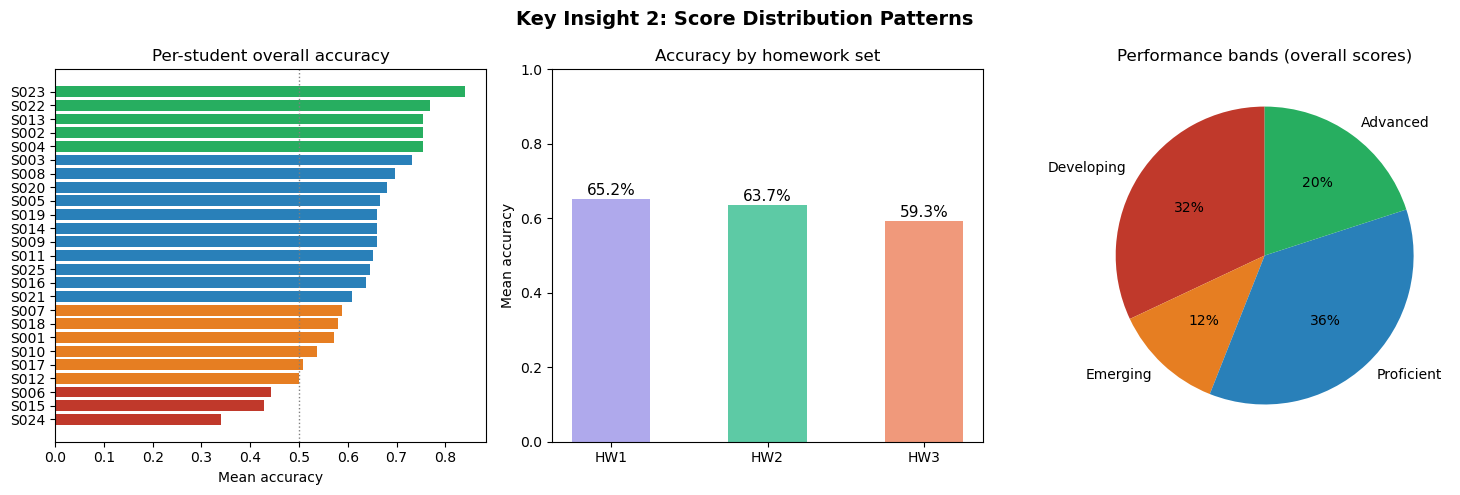

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Per-student score distribution
ax = axes[0]
stu_scores = student_obs.groupby('student_id')['score'].mean().sort_values()
band_colors = []
for v in stu_scores.values:
    if v < 0.5: band_colors.append('#C0392B')
    elif v < 0.6: band_colors.append('#E67E22')
    elif v < 0.75: band_colors.append('#2980B9')
    else: band_colors.append('#27AE60')
ax.barh(stu_scores.index, stu_scores.values, color=band_colors)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Mean accuracy')
ax.set_title('Per-student overall accuracy')

# 2. Score by HW set
ax = axes[1]
hw_acc = student_obs.groupby('assignment_id')['score'].mean()
hw_order = ['HW1','HW2','HW3']
vals = [hw_acc[h] for h in hw_order]
bars = ax.bar(hw_order, vals, color=['#AFA9EC','#5DCAA5','#F0997B'], width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}', ha='center', fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean accuracy')
ax.set_title('Accuracy by homework set')

# 3. Performance band pie
ax = axes[2]
band_counts = overall_scores['performance_band'].value_counts()
band_order = ['Developing','Emerging','Proficient','Advanced']
bcolors = ['#C0392B','#E67E22','#2980B9','#27AE60']
present = [b for b in band_order if b in band_counts.index]
pcolors = [bcolors[band_order.index(b)] for b in present]
ax.pie([band_counts[b] for b in present], labels=present, colors=pcolors,
       autopct='%1.0f%%', startangle=90)
ax.set_title('Performance bands (overall scores)')

plt.suptitle('Key Insight 2: Score Distribution Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### EXTRA


In [ ]:
# trying to find an effective visualization of the KC graph structure

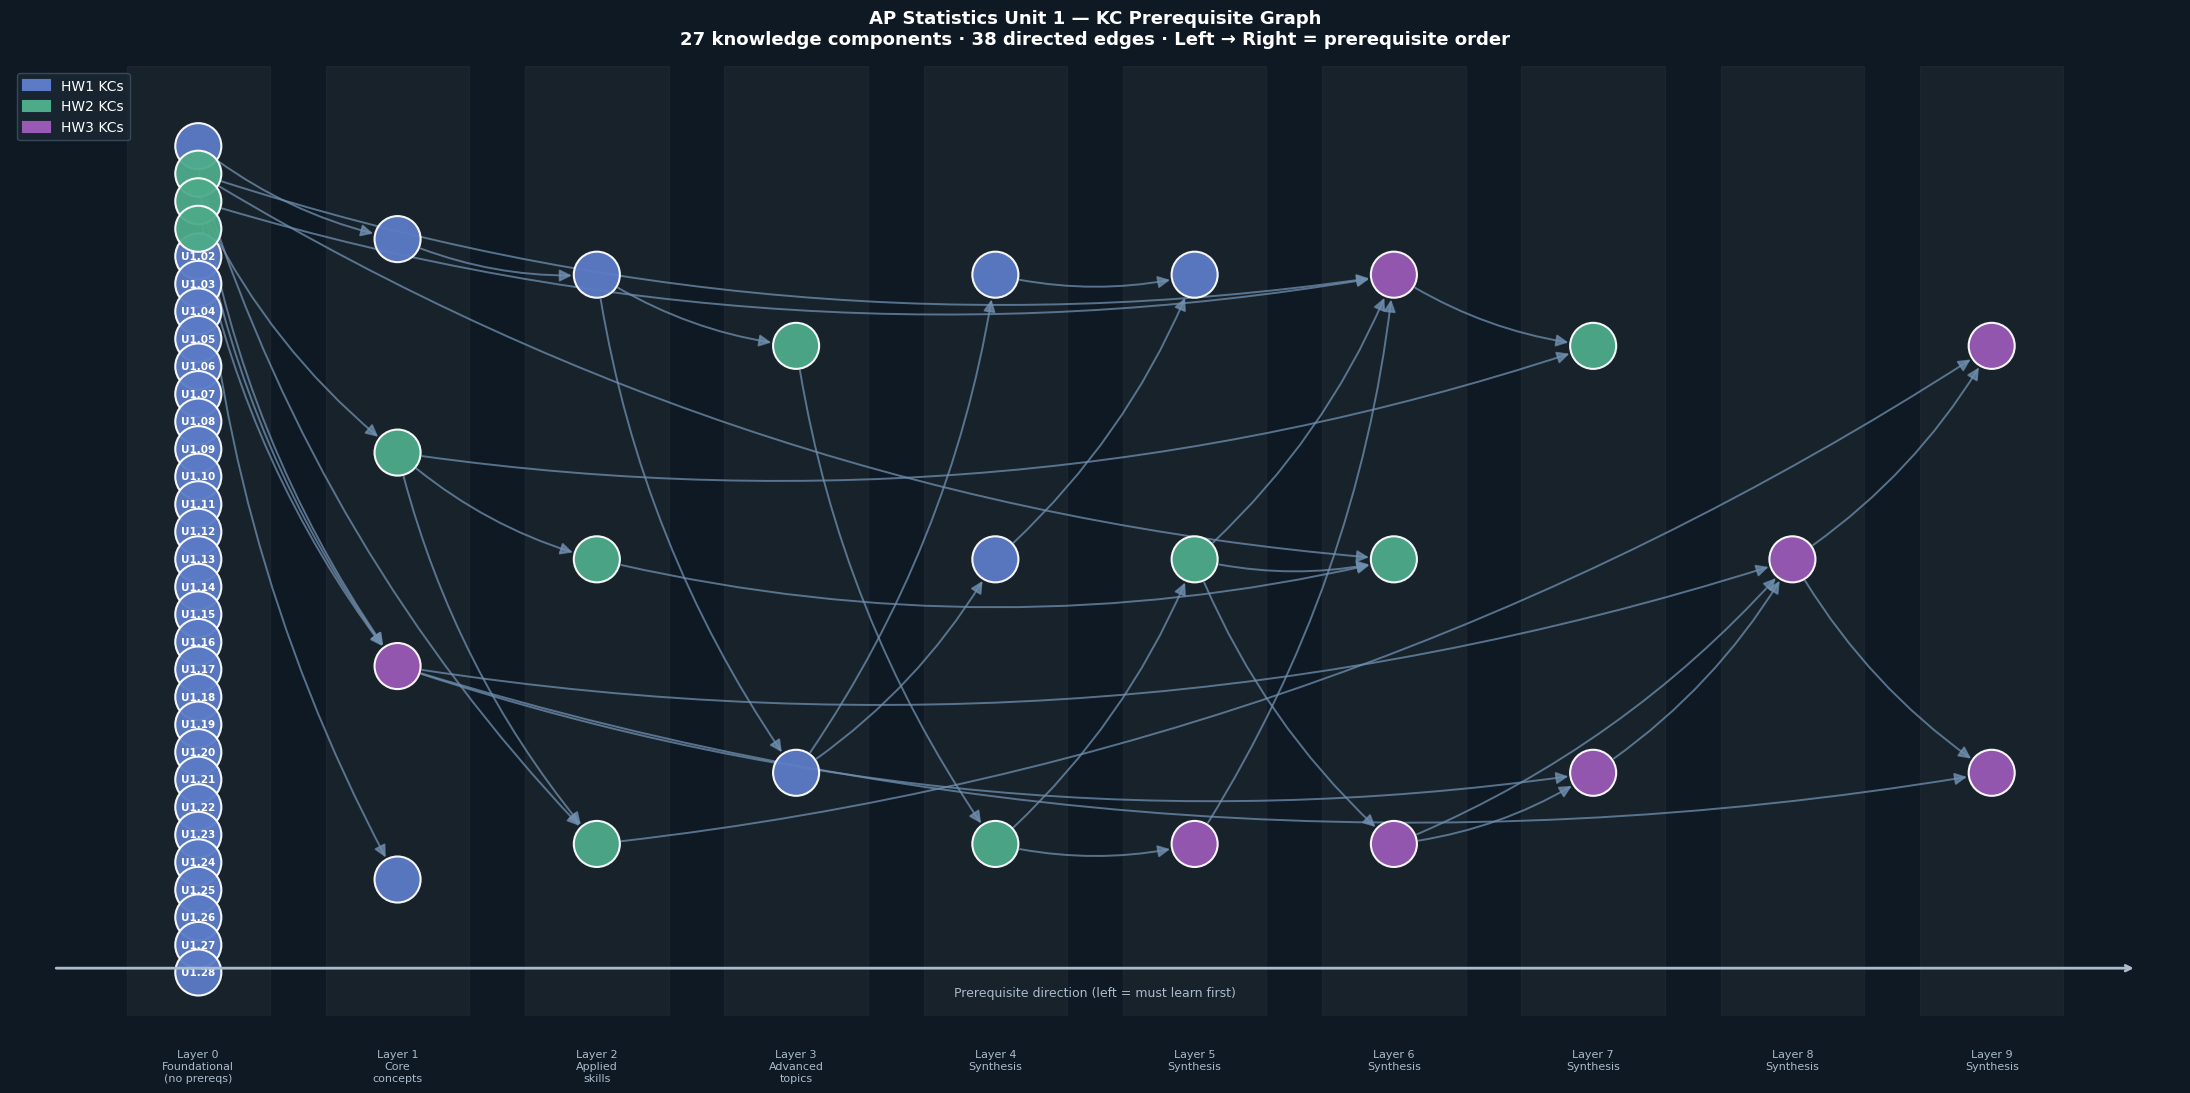

Graph is a DAG (no cycles): True
Layers found: 10  (Layer 0 = foundational roots, Layer 9 = most dependent)
  Layer 0: ['KC.U1.01.statistical_context', 'KC.U1.12.center_mean_median_mode', 'KC.U1.13.spread_iqr_range_sd', 'KC.U1.18.linear_transformations', 'U1.02', 'U1.03', 'U1.04', 'U1.05', 'U1.06', 'U1.07', 'U1.08', 'U1.09', 'U1.10', 'U1.11', 'U1.12', 'U1.13', 'U1.14', 'U1.15', 'U1.16', 'U1.17', 'U1.18', 'U1.19', 'U1.20', 'U1.21', 'U1.22', 'U1.23', 'U1.24', 'U1.25', 'U1.26', 'U1.27', 'U1.28']
  Layer 1: ['KC.U1.02.observational_unit_variable', 'KC.U1.14.five_number_boxplot', 'KC.U1.19.z_score_compute_interpret', 'KC.U1.27.sample_population_scope']
  Layer 2: ['KC.U1.03.variable_type_cat_quant', 'KC.U1.15.outlier_rule', 'KC.U1.25.percentile_quartile_interpretation']
  Layer 3: ['KC.U1.04.variable_type_discrete_continuous', 'KC.U1.05.categorical_freq_relative']
  Layer 4: ['KC.U1.06.categorical_bar_pie_segmented', 'KC.U1.07.two_way_table_association', 'KC.U1.09.quantitative_display_readi

In [27]:
# ── Compute hierarchical (layered) positions using topological sort ─────────
def hierarchical_layout(G, direction='LR'):
    """
    Position nodes in layers based on their depth in the prerequisite graph.
    direction='LR' → left-to-right flow (prerequisites on left, dependents on right)
    direction='TB' → top-to-bottom flow
    """
    # Assign each node a 'layer' = longest path from any root node
    layers = {}
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            layers[node] = 0          # root node (no prerequisites)
        else:
            layers[node] = max(layers[p] for p in predecessors) + 1

    # Group nodes by layer
    layer_groups = {}
    for node, layer in layers.items():
        layer_groups.setdefault(layer, []).append(node)

    # Assign x, y coordinates
    pos = {}
    max_layer = max(layer_groups.keys())
    for layer, nodes in layer_groups.items():
        n = len(nodes)
        for i, node in enumerate(sorted(nodes)):
            x = layer / max_layer if max_layer > 0 else 0
            y = (i - (n - 1) / 2) / max(n, 1)   # center vertically within layer
            if direction == 'TB':
                pos[node] = (y, -x)   # flip axes for top-to-bottom
            else:
                pos[node] = (x, -y)
    return pos, layers


# ── Build graph ─────────────────────────────────────────────────────────────
KC_IDS = [
    'U1.02','U1.03','U1.04','U1.05','U1.06','U1.07','U1.08',
    'U1.09','U1.10','U1.11','U1.12','U1.13','U1.14','U1.15',
    'U1.16','U1.17','U1.18','U1.19','U1.20','U1.21','U1.22',
    'U1.23','U1.24','U1.25','U1.26','U1.27','U1.28'
]

G = nx.DiGraph()
G.add_nodes_from(KC_IDS)
for _, row in kc_edges.iterrows():
    G.add_edge(row['source_kc_id'], row['target_kc_id'])

hw_color = {'HW1': '#5B7BC6', 'HW2': '#4DAB8A', 'HW3': '#9B59B6'}

kc_hw_map = (
    student_obs[['primary_kc_id', 'assignment_id']]
    .drop_duplicates('primary_kc_id')
    .set_index('primary_kc_id')['assignment_id']
    .to_dict()
)

node_colors = [
    hw_color.get(kc_hw_map.get(n, 'HW1'), '#888888')
    for n in G.nodes()
]

# ── Hierarchical positions ───────────────────────────────────────────────────
pos, layers = hierarchical_layout(G, direction='LR')

# ── Draw ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 11))
fig.patch.set_facecolor('#0F1923')
ax.set_facecolor('#0F1923')

# Layer background bands (subtle shading per depth level)
max_layer = max(layers.values())
for layer_idx in range(max_layer + 1):
    x_val = layer_idx / max_layer if max_layer > 0 else 0
    ax.axvspan(x_val - 0.04, x_val + 0.04, alpha=0.04, color='white', zorder=0)

# Draw edges FIRST (so nodes sit on top)
nx.draw_networkx_edges(
    G, pos,
    edge_color='#7090B0',
    arrows=True,
    arrowsize=18,               # bigger arrowheads
    arrowstyle='-|>',           # solid filled arrowhead
    width=1.4,
    alpha=0.75,
    connectionstyle='arc3,rad=0.12',   # slight curve prevents overlap
    min_source_margin=18,
    min_target_margin=18,
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1100,
    alpha=0.95,
    linewidths=1.5,
    edgecolors='white',
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(
    G, pos,
    labels={kc: kc for kc in KC_IDS},
    font_size=7.5,
    font_color='white',
    font_weight='bold',
    ax=ax
)

# ── Layer depth labels along the bottom ─────────────────────────────────────
layer_groups = {}
for node, layer in layers.items():
    layer_groups.setdefault(layer, []).append(node)

for layer_idx in range(max_layer + 1):
    x_val = layer_idx / max_layer if max_layer > 0 else 0
    label = ['Foundational\n(no prereqs)', 'Core\nconcepts',
             'Applied\nskills', 'Advanced\ntopics',
             'Synthesis'][min(layer_idx, 4)]
    ax.text(x_val, ax.get_ylim()[0] - 0.04 if ax.get_ylim()[0] != 0 else -0.65,
            f'Layer {layer_idx}\n{label}',
            ha='center', va='top', fontsize=8, color='#AABBCC',
            transform=ax.transData)

# ── Arrow direction guide ────────────────────────────────────────────────────
ax.annotate(
    '', xy=(0.98, 0.05), xytext=(0.02, 0.05),
    xycoords='axes fraction',
    arrowprops=dict(arrowstyle='->', color='#AABBCC', lw=2)
)
ax.text(0.50, 0.02, 'Prerequisite direction (left = must learn first)',
        transform=ax.transAxes, ha='center', fontsize=9, color='#AABBCC')

# ── Legend ───────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=c, label=f'{hw} KCs', linewidth=1.5)
    for hw, c in hw_color.items()
]
legend = ax.legend(
    handles=legend_patches,
    loc='upper left', fontsize=10,
    facecolor='#1A2733', edgecolor='#3A4D5C',
    labelcolor='white', framealpha=0.9
)

ax.set_title(
    'AP Statistics Unit 1 — KC Prerequisite Graph\n'
    '27 knowledge components · 38 directed edges · Left → Right = prerequisite order',
    fontsize=13, fontweight='bold', color='white', pad=16
)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Graph is a DAG (no cycles): {nx.is_directed_acyclic_graph(G)}")
print(f"Layers found: {max_layer + 1}  (Layer 0 = foundational roots, Layer {max_layer} = most dependent)")
for layer_idx in sorted(layer_groups):
    print(f"  Layer {layer_idx}: {sorted(layer_groups[layer_idx])}")

In [26]:
(
    student_obs[['primary_kc_id', 'assignment_id']]
    .drop_duplicates('primary_kc_id')
    .set_index('primary_kc_id')['assignment_id']
    .to_dict()
)


{'KC.U1.02.observational_unit_variable': 'HW1',
 'KC.U1.03.variable_type_cat_quant': 'HW1',
 'KC.U1.05.categorical_freq_relative': 'HW1',
 'KC.U1.06.categorical_bar_pie_segmented': 'HW1',
 'KC.U1.07.two_way_table_association': 'HW1',
 'KC.U1.08.graph_choice_categorical': 'HW1',
 'KC.U1.27.sample_population_scope': 'HW1',
 'KC.U1.04.variable_type_discrete_continuous': 'HW2',
 'KC.U1.09.quantitative_display_reading': 'HW2',
 'KC.U1.10.histogram_shape_features': 'HW2',
 'KC.U1.12.center_mean_median_mode': 'HW2',
 'KC.U1.13.spread_iqr_range_sd': 'HW2',
 'KC.U1.15.outlier_rule': 'HW2',
 'KC.U1.16.resistance_skew_mean_median': 'HW2',
 'KC.U1.14.five_number_boxplot': 'HW2',
 'KC.U1.17.compare_distributions': 'HW2',
 'KC.U1.18.linear_transformations': 'HW2',
 'KC.U1.25.percentile_quartile_interpretation': 'HW2',
 'KC.U1.21.empirical_rule_sd': 'HW3',
 'KC.U1.20.normal_model_appropriateness': 'HW3',
 'KC.U1.22.normal_tail_interval_probability': 'HW3',
 'KC.U1.23.inverse_normal_percentile': 'HW3'

## MODELLING

In [28]:
bkt_data = student_obs[student_obs['score'] != 0.5].copy()
bkt_data['correct'] = bkt_data['score'].astype(int)

bkt_data = bkt_data.rename(columns={
    'student_id':     'user_id',
    'primary_kc_id':  'skill_name',
    'observation_id': 'order_id'
})[['user_id', 'skill_name', 'correct', 'order_id']]

In [32]:
bkt_data.head()

,user_id,skill_name,correct,order_id
0,S001,KC.U1.02.observational_unit_variable,0,HW1_PCA_Q01
1,S001,KC.U1.03.variable_type_cat_quant,1,HW1_PCA_Q02
2,S001,KC.U1.03.variable_type_cat_quant,0,HW1_PCA_Q03
3,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q04
4,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q05


In [33]:
bkt_data = bkt_data.sort_values(['user_id', 'order_id']).reset_index(drop=True)

bkt_data.head()

,user_id,skill_name,correct,order_id
0,S001,KC.U1.02.observational_unit_variable,0,HW1_PCA_Q01
1,S001,KC.U1.03.variable_type_cat_quant,1,HW1_PCA_Q02
2,S001,KC.U1.03.variable_type_cat_quant,0,HW1_PCA_Q03
3,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q04
4,S001,KC.U1.05.categorical_freq_relative,1,HW1_PCA_Q05


In [40]:
floor_kcs = kc_obs_counts[kc_obs_counts['obs_count'] <= 25]['kc_id'].tolist()

bkt_data_full = bkt_data.copy()
bkt_data = bkt_data[~bkt_data['skill_name'].isin(floor_kcs)].copy()

In [42]:
print(f"Total rows (all KCs):       {len(bkt_data_full):,}")
print(f"Rows after removing floors: {len(bkt_data):,}")
print(f"KCs included:               {bkt_data['skill_name'].nunique()}")
print(f"Students:                   {bkt_data['user_id'].nunique()}")
print(f"Correct rate:               {bkt_data['correct'].mean():.1%}")

Total rows (all KCs):       1,692
Rows after removing floors: 1,452
KCs included:               18
Students:                   25
Correct rate:               62.9%


In [43]:
bkt_data.isnull().sum()

user_id       0
skill_name    0
correct       0
order_id      0
dtype: int64

In [44]:
bkt_data['correct'].unique()

array([1, 0])

**The 4 parameters BKT estimates for each KC:**

| Parameter | Symbol | Question it answers |
|---|---|---|
| Prior | p(L₀) | What fraction of students likely knew this KC before the course started? |
| Learn | p(T) | After each practice attempt, how likely is a student to learn the KC? |
| Guess | p(G) | If a student does NOT know the KC, what is the chance of a lucky correct answer? |
| Slip | p(S) | If a student DOES know the KC, what is the chance of a careless wrong answer? |